In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\verma\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('gurgaon_properties_outliers_treated.csv')

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room
0,flat,the close north,sector 50,2.35,11768.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,3,3+,8.0,North-East,Moderately Old,1997.0,1950.0,1850.0,0,0,0,0,0,2,165,665.666667
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,10.0,East,New Property,2585.0,NaN,NaN,0,1,0,0,1,0,74,861.666667
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,3,3,2,2.0,West,Moderately Old,NaN,241.0,240.0,0,1,0,0,0,2,66,720.000000
3,flat,rof ananda,sector 95,0.46,6319.0,728.0,Carpet area: 728 (67.63 sq.m.),2,2,2,11.0,North-West,New Property,NaN,NaN,728.0,1,0,0,0,0,0,82,364.000000
4,house,prem kunj,sohna road road,0.50,7407.0,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 s...,2,4,3,3.0,South-West,Relatively New,NaN,725.0,675.0,0,0,0,1,0,0,22,337.500000


In [8]:
df.isnull().sum()/df.shape[0]*100

property_type           0.000000
society                 0.028129
sector                  0.000000
price                   0.000000
price_per_sqft          0.000000
area                    0.000000
areaWithType            0.000000
bedRoom                 0.000000
bathroom                0.000000
balcony                 0.000000
floorNum                0.478200
facing                 28.438819
agePossession           0.000000
super_built_up_area    47.257384
built_up_area          55.358650
carpet_area            48.241913
study room              0.000000
servant room            0.000000
store room              0.000000
pooja room              0.000000
others                  0.000000
furnishing_type         0.000000
luxury_score            0.000000
area_room               0.000000
dtype: float64

### Built up area

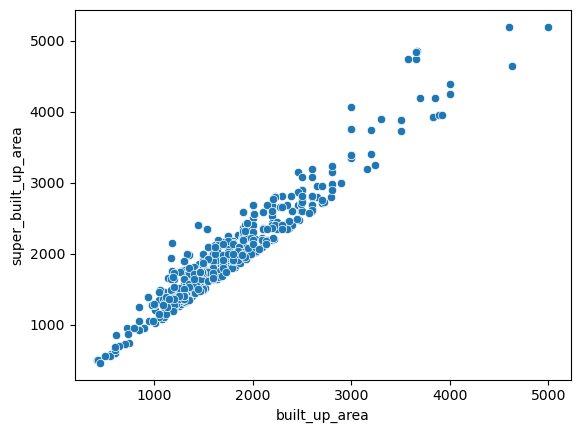

In [11]:
sns.scatterplot(x='built_up_area',y='super_built_up_area',data=df);

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

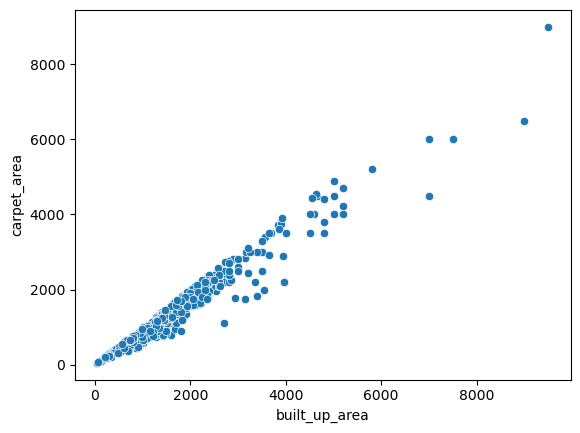

In [12]:
sns.scatterplot(x='built_up_area',y='carpet_area',data=df)

In [15]:
# here i am checking is there any row where all these three are missing in the same row
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())).sum()
# luckily there is not row where all 3 rows are missing

0

In [17]:
# here i am fetching those rows where all three are present
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]
all_present_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room
0,flat,the close north,sector 50,2.35,11768.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,3,3+,8.0,North-East,Moderately Old,1997.0,1950.0,1850.0,0,0,0,0,0,2,165,665.666667
10,flat,dlf the ultima,sector 81,2.20,10461.0,2103.0,Super Built up area 2103(195.38 sq.m.)Built Up...,3,3,3+,5.0,East,Relatively New,2103.0,1570.0,1257.0,1,1,0,1,1,1,49,701.000000
21,flat,sunischit apartments,sector 54,1.75,7955.0,2200.0,Super Built up area 2200(204.39 sq.m.)Built Up...,3,3,3+,6.0,North-East,Moderately Old,2200.0,2100.0,2000.0,0,1,0,0,0,2,126,733.333333
29,flat,siddhi vinayak apartments,sector 55,1.44,9600.0,1500.0,Super Built up area 1850(171.87 sq.m.)Built Up...,3,3,2,6.0,South,Moderately Old,1850.0,1700.0,1500.0,0,0,0,0,1,2,47,500.000000
31,flat,paras dews,sector 106,1.15,6534.0,1760.0,Super Built up area 1760(163.51 sq.m.)Built Up...,3,4,3+,12.0,East,Relatively New,1760.0,1186.0,1130.0,1,1,0,0,0,2,174,586.666667


In [18]:
all_present_df.shape

(531, 24)

In [19]:
# calculating the super_to_built_up_ratio
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [20]:
# carpet_to_built_up_ratio
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [21]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [22]:
# fetching those rows where super_built_up_area ,carpet_area is present but built_up_area is null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [23]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room
5,flat,central park 2 bellevue,sector 48,2.75,10755.0,2557.0,Super Built up area 2557(237.55 sq.m.)Carpet a...,3,4,3+,3.0,NaN,Moderately Old,2557.0,NaN,2550.00,0,0,0,0,0,0,32,852.333333
8,flat,hsiidc sidco shivalik apartments,manesar,0.48,3840.0,1250.0,Super Built up area 1250(116.13 sq.m.)Carpet a...,2,2,3,7.0,South,Moderately Old,1250.0,NaN,770.00,0,0,0,0,0,0,88,625.000000
19,flat,signature global the millennia,sector 37d,0.60,9231.0,650.0,Super Built up area 650(60.39 sq.m.)Carpet are...,2,2,3,7.0,NaN,New Property,650.0,NaN,596.12,0,0,0,0,0,0,35,325.000000
20,flat,pareena laxmi apartments,sector 99a,0.32,6107.0,524.0,Super Built up area 524(48.68 sq.m.)Carpet are...,2,2,2,2.0,NaN,New Property,524.0,NaN,424.80,0,0,0,0,0,0,50,262.000000
23,flat,cghs vidya enclave,sector 56,1.70,10968.0,1550.0,Super Built up area 1600(148.64 sq.m.)Carpet a...,3,2,3,6.0,NaN,Old Property,1600.0,NaN,1550.00,0,0,1,0,0,0,101,516.666667


In [24]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\verma\AppData\Local\Temp\ipykernel_19856\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\verma\AppData\Local\Temp\ipykernel_19856\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

In [25]:
df.update(sbc_df)

In [26]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1547
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room                 0
dtype: int64

In [27]:
# fetching those rows where super_built_up_area is present  ,but carpet_area is null and also built_up_area is null

sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [28]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,10.0,East,New Property,2585.0,NaN,NaN,0,1,0,0,1,0,74,861.666667
9,flat,jammu and kashmir bank employees cghs,sector 9a,0.95,6129.0,1550.0,Super Built up area 1550(144 sq.m.),3,3,2,5.0,West,Moderately Old,1550.0,NaN,NaN,0,0,0,0,1,0,30,516.666667
16,flat,eldeco accolade,sohna road,0.78,5420.0,1439.0,Super Built up area 1457(135.36 sq.m.),2,2,2,7.0,North,Relatively New,1457.0,NaN,NaN,1,0,0,0,0,2,137,719.500000
22,flat,godrej nature plus,sector 33,1.35,8232.0,1640.0,Super Built up area 1640(152.36 sq.m.),3,2,3+,7.0,North-East,Undefined,1640.0,NaN,NaN,0,0,0,1,0,0,49,546.666667
26,flat,pareena coban residences,sector 99a,1.45,7261.0,1997.0,Super Built up area 1997(185.53 sq.m.),3,5,3,11.0,NaN,Relatively New,1997.0,NaN,NaN,0,1,0,0,1,2,49,665.666667


In [29]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\verma\AppData\Local\Temp\ipykernel_19856\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\verma\AppData\Local\Temp\ipykernel_19856\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(rou

In [30]:
df.update(sb_df)

In [31]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area           672
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room                 0
dtype: int64

In [32]:
# fetching those rows where super_built_up_area is null  and also built_up_area is null but  carpet_area is present

c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [33]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room
3,flat,rof ananda,sector 95,0.46,6319.0,728.0,Carpet area: 728 (67.63 sq.m.),2,2,2,11.0,North-West,New Property,NaN,NaN,728.0,1,0,0,0,0,0,82,364.0
13,flat,pyramid urban homes 2,sector 86,0.41,6902.0,594.0,Carpet area: 601 (55.83 sq.m.),2,2,1,3.0,West,Relatively New,NaN,NaN,601.0,0,0,0,0,0,0,63,297.0
34,flat,m3m capital,sector 113,2.87,12489.0,2298.0,Carpet area: 2298 (213.49 sq.m.),4,4,3+,3.0,North-East,Under Construction,NaN,NaN,2298.0,0,1,0,0,0,0,65,574.5
46,flat,signature global synera,sector 81,0.45,7525.0,598.0,Carpet area: 598 (55.56 sq.m.),2,2,2,6.0,North-East,Relatively New,NaN,NaN,598.0,0,0,1,0,0,2,39,299.0
49,flat,godrej,sector 79,1.41,8998.0,1567.0,Carpet area: 1572 (146.04 sq.m.),2,2,3,3.0,NaN,New Property,NaN,NaN,1572.0,1,0,0,0,0,0,104,783.5


In [34]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\verma\AppData\Local\Temp\ipykernel_19856\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\verma\AppData\Local\Temp\ipykernel_19856\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carp

In [35]:
df.update(c_df)

In [36]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area             0
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room                 0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

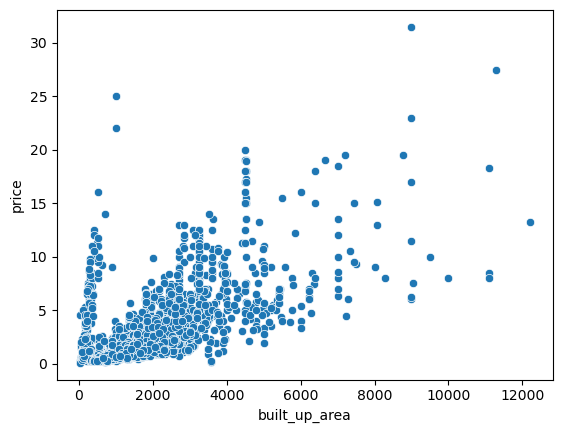

In [38]:
sns.scatterplot(x='built_up_area',y='price',data=df)

In [39]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [41]:
# here ares is justifying the price but built_up_area not
anamoly_df.sample(5)

,price,area,built_up_area
347,2.60,1711.0,1548.0
981,6.46,3420.0,380.0
2382,9.00,8100.0,900.0
2460,4.85,1607.0,1785.0
699,2.75,1080.0,1080.0


In [42]:
# replacing the builtup_area value by area
anamoly_df['built_up_area'] = anamoly_df['area']

In [43]:
df.update(anamoly_df)

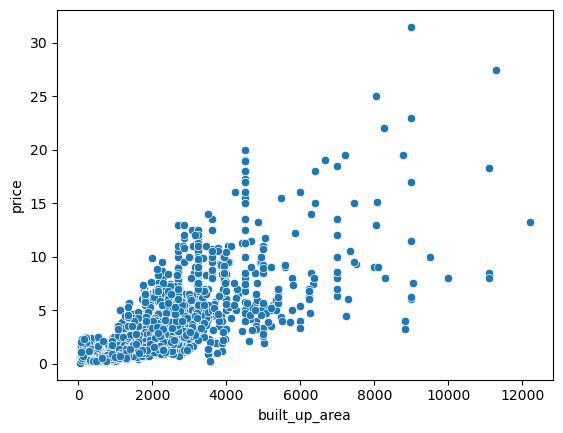

In [45]:
sns.scatterplot(x='built_up_area',y='price',data=df);

In [47]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room'],inplace=True)

In [48]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,the close north,sector 50,2.35,11768.0,3,3,3+,8.0,North-East,Moderately Old,1950.0,0,0,0,0,0,2,165
1,flat,ats tourmaline,sector 109,2.30,8897.0,3,4,3+,10.0,East,New Property,2339.0,0,1,0,0,1,0,74
2,house,unitech espace,sector 50,7.50,34722.0,3,3,2,2.0,West,Moderately Old,2160.0,0,1,0,0,0,2,66
3,flat,rof ananda,sector 95,0.46,6319.0,2,2,2,11.0,North-West,New Property,809.0,1,0,0,0,0,0,82
4,house,prem kunj,sohna road road,0.50,7407.0,2,4,3,3.0,South-West,Relatively New,725.0,0,0,0,1,0,0,22


In [49]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### floorNum

In [50]:
# after starring the data i thought that for filling the values in floor column the proper type will help me
# in this data there are only 2 flats (in this 1 float is that kind where society values is missing)
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
63,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,0,9
163,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,NaN,Old Property,360.0,0,0,0,0,0,0,0
258,flat,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,0,0
719,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,5200.0,0,1,1,1,0,2,114
944,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately Old,3240.0,0,1,1,1,0,0,88
1107,house,independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,0,0
1406,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,585.0,0,0,0,0,0,0,0
2064,house,ansal sushant lok,sector 43,10.50,27911.0,4,4,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,0,59
2111,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,0,0
2194,house,independent,sector 24,1.45,2984.0,3,3,1,NaN,NaN,Old Property,540.0,0,0,0,0,0,0,9


In [51]:
# calculating the median for floorNum of all houses
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [52]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\verma\AppData\Local\Temp\ipykernel_19856\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [53]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [54]:
1011/df.shape[0]

0.2843881856540084

### facing

<Axes: ylabel='count'>

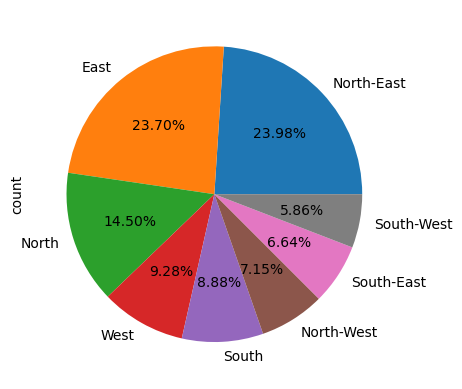

In [55]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [56]:
df.drop(columns=['facing'],inplace=True)

In [57]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3101,flat,vatika gurgaon,sector 83,1.12,6455.0,3,3,2,17.0,Moderately Old,1500.0,0,0,0,0,0,2,111
1519,flat,mittal cosmos executive apartments,sector 2,0.75,6550.0,2,2,2,15.0,Old Property,1100.0,0,0,0,0,0,2,42
1533,flat,sare homes,new,0.85,4786.0,4,4,3,3.0,Moderately Old,1607.0,0,0,0,0,0,0,0
1167,flat,mapsko mount ville,sector 79,1.25,8389.0,3,3,3+,16.0,Relatively New,1656.0,0,0,0,0,0,2,49
2538,flat,la vida by tata housing,sector 113,1.85,11716.0,3,2,2,7.0,New Property,1429.0,0,0,0,0,0,0,13


In [58]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [61]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2454,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,0,0


In [62]:
df.drop(index=[2454],inplace=True)

In [63]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [64]:
df['agePossession'].value_counts()

agePossession
Relatively New        1604
New Property           557
Moderately Old         545
Undefined              431
Old Property           293
Under Construction     123
Name: count, dtype: int64

In [65]:
# after starring the that i get to know that to handle this undefined category
#  peoperty_type and society colum will help me out 
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
7,flat,godrej air,sector 85,1.05,10606.0,2,2,1,15.0,Undefined,97.0,0,0,0,0,0,0,45
18,flat,shree vardhman flora,sector 90,0.80,5926.0,2,3,2,0.0,Undefined,1350.0,0,0,0,0,0,0,60
22,flat,godrej nature plus,sector 33,1.35,8232.0,3,2,3+,7.0,Undefined,1484.0,0,0,0,1,0,0,49
25,house,independent,sector 43,5.75,23663.0,4,4,2,4.0,Undefined,2430.0,0,1,1,0,0,1,153
41,house,independent,sector 31,4.60,32258.0,2,2,2,2.0,Undefined,1426.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3494,flat,dlf the arbour,sector 63,8.50,21519.0,4,4,0,27.0,Undefined,3950.0,0,0,0,0,0,0,61
3505,flat,godrej nature plus,sector 33,1.08,13123.0,2,2,3,8.0,Undefined,85.0,0,0,0,0,0,0,56
3506,house,independent,sector 7,2.25,16892.0,5,3,0,2.0,Undefined,148.0,0,0,0,0,0,0,0
3517,flat,godrej nature plus,sector 33,1.75,8768.0,3,3,0,2.0,Undefined,1996.0,0,0,0,0,0,0,56


In [72]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [73]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [74]:
df['agePossession'].value_counts()

agePossession
Relatively New        1780
New Property           635
Moderately Old         587
Old Property           331
Under Construction     125
Undefined               95
Name: count, dtype: int64

In [75]:
# here filling according to sector basis
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [76]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [77]:
df['agePossession'].value_counts()

agePossession
Relatively New        1796
New Property           661
Moderately Old         594
Old Property           342
Under Construction     125
Undefined               35
Name: count, dtype: int64

In [78]:
# here filling according to property type basis
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [79]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [80]:
df['agePossession'].value_counts()

agePossession
Relatively New        1808
New Property           661
Moderately Old         617
Old Property           342
Under Construction     125
Name: count, dtype: int64

In [81]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [82]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [83]:
df.shape

(3553, 18)